<a href="https://colab.research.google.com/github/armybonita/Good-Energy-Intelligence-Score/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Convolusion Neural Network

## Convolution이란?  

이 섹션에서는 CNN 의 메커니즘의 핵심 조건인 합성곱(Convolution) 연산을 설명하며 CNN 아키텍쳐를 구현하고 학습해본 뒤 MLP와 비교한다.

### 환경 설정 및 데이터 준비

In [ ]:
! pip -q install colorama
! wget -q https://github.com/theevann/webconf-pytorch-workshop/raw/master/figures/image-city.jpg

import sys
import colorama
from collections import OrderedDict
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.set_printoptions(precision=3)

### 1D Convolution

합성곱(Convolution)은 두 신호 간의 연산이다. 컴퓨터 비전 도메인에서 하나의 신호는 주로 입력(Input; 오디오 신호, 이미지 등)으로 정의되며, 다른 하나의 신호는 필터(Filter) 혹은 커널(Kernel)로 명명된다.

입력 벡터와 커널 간의 합성곱 산출물(Output)을 도출하는 연산 절차는 다음과 같다.

- 입력 데이터의 모든 가능한 위치에 대해 커널을 슬라이딩(Sliding)한다.

- 각 위치에서 커널과 이에 대응하는 입력 영역 간의 원소별 곱(Element-wise product)을 수행한다.

- 산출된 원소별 곱의 결과를 모두 합산(Sum)한다.

![image](https://github.com/theevann/webconf-pytorch-workshop/blob/master/figures/conv-1d.gif?raw=1)


제안하는 연산은 PyTorch 프레임워크 내에서 torch.nn.functional.conv1d 함수를 활용하여 수행할 수 있다.

In [ ]:
input = torch.Tensor([1,4,-1,0,2,-2,1,3,3,1]).view(1,1,-1)  # Size: (Batch size, Num Channels, Input size)
kernel = torch.Tensor([1,2,0,-1]).view(1,1,-1)  # Size: (Num output channels, Num input channels, Kernel size)

torch.nn.functional.conv1d(input, kernel)

tensor([[[ 9.,  0.,  1.,  3., -5., -3.,  6.]]])

### 2D Convolution

2차원 공간으로의 확장은 수학적으로 자명하다. 기본 연산 메커니즘은 유지되나, 입력(Input) 및 커널(Kernel) 텐서가 모두 2차원 구조로 재정의된다.

![image](https://github.com/theevann/webconf-pytorch-workshop/blob/master/figures/conv-2ds.gif?raw=1)

제안하는 연산은 PyTorch 프레임워크 내에서 torch.nn.functional.conv2d 함수를 활용하여 수행할 수 있다.

### nn.Module 내의 합성곱(Convolutions)
nn.Module 내부에서 합성곱 계층을 구성할 때는 일반적으로 nn.Conv2d 모듈을 사용한다.

합성곱 연산에 필요한 커널(Kernels)은 nn.Conv2d 인스턴스 생성 시 직접 정의 및 초기화된다.

In [ ]:
conv_1 = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=(3,3))

print("Convolution", conv_1)
print("Kernel size: ", conv_1.weight.shape) # First two dimensions are: Num output channels and Num input channels

Convolution Conv2d(3, 2, kernel_size=(3, 3), stride=(1, 1))
Kernel size:  torch.Size([2, 3, 3, 3])


In [ ]:
# Fake 5x5 input with 3 channels
input = torch.randn(1, 3, 5, 5)  # batch_size, num_channels, height, width

out = conv_1(input)
print(out)

tensor([[[[ 0.006,  0.513,  0.326],
          [ 0.114,  0.189,  0.347],
          [-0.676, -0.353, -0.585]],

         [[ 0.454, -0.367,  0.095],
          [ 0.716, -0.386,  0.232],
          [-0.424, -0.964,  0.658]]]], grad_fn=<ConvolutionBackward0>)


## CNN 신경망 만들기
학습 과제로 다시 한번 MNIST 분류 데이터셋을 활용한다.

다만, 이번에는 합성곱 신경망(CNN)을 사용하여 문제를 해결하고자 한다.

PyTorch를 활용하여 LeNet-5 CNN 아키텍처를 구축한다.

### Defining the LeNet-5 architecture

![image](https://pytorch.org/tutorials/_images/mnist.png)

*Y. LeCun, L. Bottou, Y. Bengio, and P. Haffner. "Gradient-based learning applied to document recognition." Proceedings of the IEEE, 86(11):2278-2324, November 1998.*

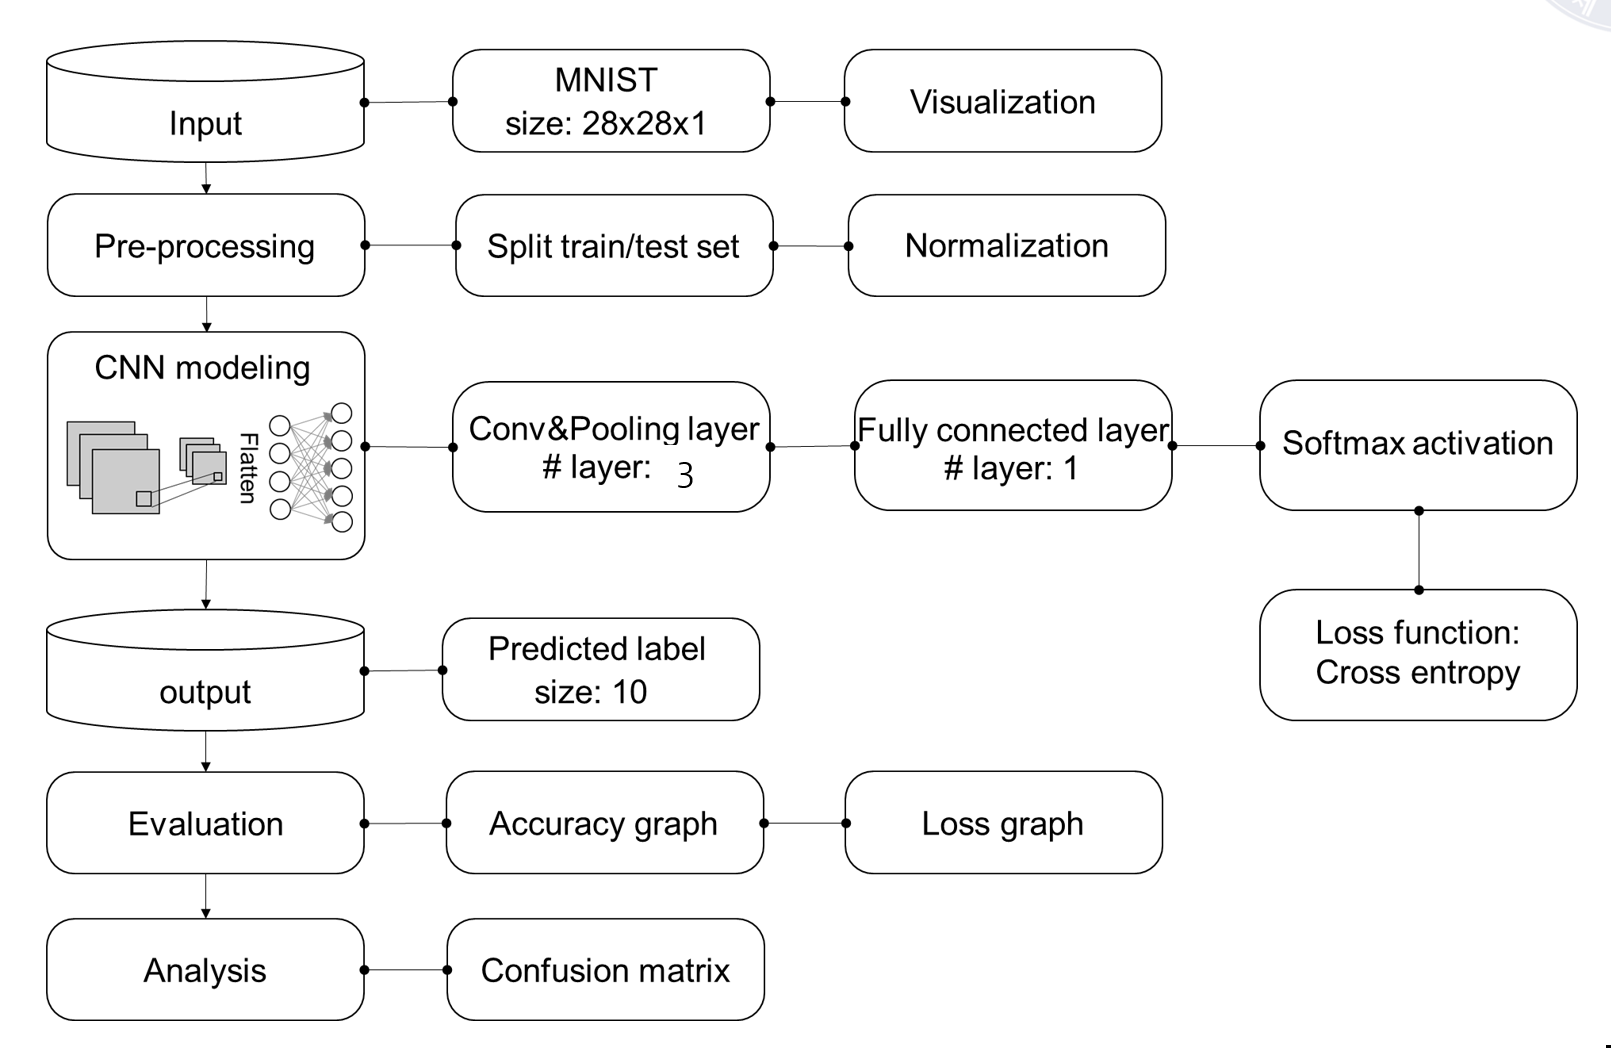

### LeNet-5 아키텍처 명세 (Architecture Specification)

*참고: 마지막 계층의 가우시안 연결(Gaussian connections)은 적합도 부족(lack of fit)을 추정하기 위해 사용되었습니다. 본 구현에서는 현대적인 관례에 따라 교차 엔트로피 손실 함수(cross-entropy loss function)를 사용합니다. 이와 유사하게, tanh 활성화 함수 대신 ReLU를 적용합니다.*

**아키텍처 세부 사항**

* **합성곱부 (Convolutional part):**

| 계층 (Layer) | 명칭 (Name) | 입력 채널 | 출력 채널 | 커널 (Kernel) | 스트라이드 (Stride) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| Convolution | C1 | 1 | 6 | 5x5 | 1 |
| ReLU | | 6 | 6 | | |
| MaxPooling | S2 | 6 | 6 | 2x2 | 2 |
| Convolution | C3 | 6 | 16 | 5x5 | 1 |
| ReLU | | 16 | 16 | | |
| MaxPooling | S4 | 16 | 16 | 2x2 | 2 |
| Convolution | C5 | 16 | 120 | 5x5 | 1 |
| ReLU | | 120 | 120 | | |

* **완전 연결부 (Fully Connected part):**

| 계층 (Layer) | 명칭 (Name) | 입력 크기 | 출력 크기 |
| :--- | :---: | :---: | :---: |
| Linear | F5 | 120 | 84 |
| ReLU | | | |
| Linear | F6 | 84 | 10 |
| LogSoftmax | | | |

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv_part = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=(5,5), stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=(5,5), stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=2),
            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=(5,5), stride=1),
            nn.ReLU()
        )
        self.fc_part = nn.Sequential(
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(),
            nn.Linear(in_features=84, out_features=10),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, imgs):
        x = self.conv_part(imgs) ## resize 없음
        x = torch.flatten(x, 1) # Flatten the tensor starting from dimension 1 (batch dimension is 0)
        output = self.fc_part(x)
        return output

#### 네트워크 형태 확인하기

In [ ]:
conv_net = LeNet5()
print(conv_net)

LeNet5(
  (conv_part): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): ReLU()
  )
  (fc_part): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
    (2): Linear(in_features=84, out_features=10, bias=True)
    (3): LogSoftmax(dim=1)
  )
)


#### 학습 가능한 파라미터 확인하기

In [ ]:
named_params = list(conv_net.named_parameters())
print("len(params): %s\n" % len(named_params))

for name, param in named_params:
    print("%s:\t%s" % (name, param.shape))

len(params): 10

conv_part.0.weight:	torch.Size([6, 1, 5, 5])
conv_part.0.bias:	torch.Size([6])
conv_part.3.weight:	torch.Size([16, 6, 5, 5])
conv_part.3.bias:	torch.Size([16])
conv_part.6.weight:	torch.Size([120, 16, 5, 5])
conv_part.6.bias:	torch.Size([120])
fc_part.0.weight:	torch.Size([84, 120])
fc_part.0.bias:	torch.Size([84])
fc_part.2.weight:	torch.Size([10, 84])
fc_part.2.bias:	torch.Size([10])


### CNN 네트워크 학습하기

#### 학습 함수 (Train function)

이전 노트북과 유사하게, 모델 학습을 위한 `train_cnn` 함수를 정의한다.

In [ ]:
def get_test_metrics(model, dataloader, criterion, device):
    model.eval() # Set the model to evaluation mode
    test_loss = 0
    correct = 0
    with torch.no_grad(): # Disable gradient calculation for inference
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            output = model(data)
            # Sum up batch loss, scaled by batch size
            test_loss += criterion(output, labels).item() * data.size(0)
            pred = output.max(1, keepdim=True)[1] # Get the index of the max log-probability
            correct += pred.eq(labels.view_as(pred)).sum().item()

    test_loss /= len(dataloader.dataset)
    test_acc = correct / len(dataloader.dataset)
    return test_acc, test_loss

def train_cnn(model, train_loader, test_loader, device, num_epochs=3, lr=0.1):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(num_epochs):
        print("=" * 40, "Starting epoch %d" % (epoch + 1), "=" * 40)
        model.train()

        for batch_idx, (data, labels) in enumerate(train_loader):
            data, labels = data.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            # Iteration 단위로 loss 저장
            train_losses.append(loss.item())

            if batch_idx % 40 == 0:
                print("Batch %d/%d, Loss=%.4f" % (batch_idx, len(train_loader), loss.item()))

        # Epoch 단위로 accuracy와 test loss 계산
        train_acc = accuracy(model, train_loader, device)
        test_acc, avg_test_loss = get_test_metrics(model, test_loader, criterion, device)

        test_losses.append(avg_test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(colorama.Fore.GREEN, "\nAccuracy on training: %.2f%%" % (100*train_acc))
        print("Accuracy on test: %.2f%%" % (100*test_acc), colorama.Fore.RESET)

    return train_losses, test_losses, train_accs, test_accs

#### 테스트 함수 (Test function)

훈련 및 테스트 데이터셋에 대한 모델의 분류 성능을 정량적으로 평가하기 위해 `accuracy` 함수를 정의한다.

In [ ]:
def accuracy(model, dataloader, device):
    """ Computes the model's accuracy on the data provided by 'dataloader'
    """
    model.eval()

    num_correct = 0
    num_samples = 0
    with torch.no_grad():  # deactivates autograd, reduces memory usage and speeds up computations
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)

            predictions = model(data).max(1)[1]  # indices of the maxima along the second dimension
            num_correct += (predictions == labels).sum().item()
            num_samples += predictions.shape[0]

    return num_correct / num_samples

#### *`DataLoader`*를 활용한 훈련 및 테스트 데이터 로딩

In [ ]:
from torchvision import datasets, transforms

transformations = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

train_data = datasets.MNIST('./data',
                            train = True,
                            download = True,
                            transform = transformations)

test_data = datasets.MNIST('./data',
                            train = False,
                            download = True,
                            transform = transformations)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1024, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.25MB/s]


#### 학습 시작

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conv_net = LeNet5().to(device)

# 학습을 진행하고 지표 리스트를 받아옵니다.
train_losses, test_losses, train_accs, test_accs = train_cnn(conv_net, train_loader, test_loader, device, lr=2e-3)

======================================== Starting epoch 1 ========================================
Batch 0/235, Loss=2.3015
Batch 40/235, Loss=0.7266
Batch 80/235, Loss=0.2703
Batch 120/235, Loss=0.2272
Batch 160/235, Loss=0.1027
Batch 200/235, Loss=0.0869
 
Accuracy on training: 96.25%
Accuracy on test: 96.36% 
======================================== Starting epoch 2 ========================================
Batch 0/235, Loss=0.1328
Batch 40/235, Loss=0.1178
Batch 80/235, Loss=0.1130
Batch 120/235, Loss=0.0779
Batch 160/235, Loss=0.1240
Batch 200/235, Loss=0.1110
 
Accuracy on training: 97.88%
Accuracy on test: 98.15% 
======================================== Starting epoch 3 ========================================
Batch 0/235, Loss=0.0800
Batch 40/235, Loss=0.0758
Batch 80/235, Loss=0.1116
Batch 120/235, Loss=0.1006
Batch 160/235, Loss=0.0664
Batch 200/235, Loss=0.0430
 
Accuracy on training: 98.07%
Accuracy on test: 98.14% 


#### 모델 예측 확인하기

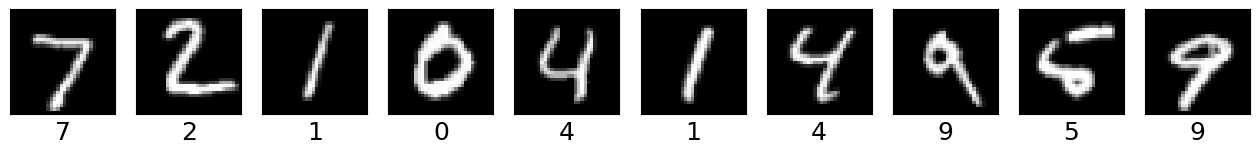

In [ ]:
def visualize_predictions(model, dataloader, device):
    data, labels = next(iter(dataloader))
    data, labels = data[:10].to(device), labels[:10]
    predictions = model(data).max(1)[1]

    predictions, data = predictions.cpu(), data.cpu()

    plt.figure(figsize=(16,9))
    for i in range(10):
        img = data.squeeze(1)[i]
        plt.subplot(1, 10, i+1)
        plt.imshow(img, cmap="gray", interpolation="none")
        plt.xlabel(predictions[i].item(), fontsize=18)
        plt.xticks([])
        plt.yticks([])

visualize_predictions(conv_net, test_loader, device)

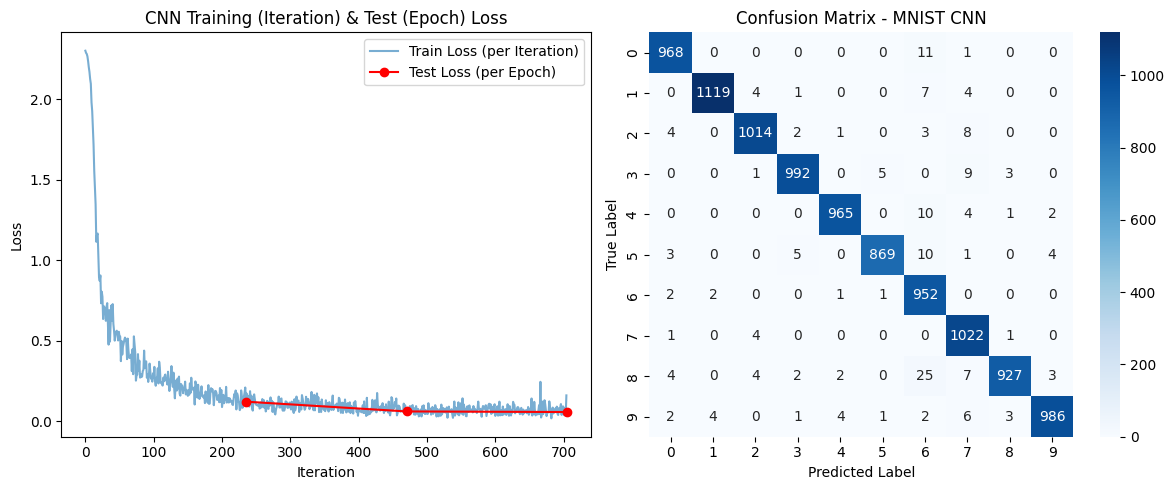

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Loss 그래프 시각화 (Iteration 단위 Train Loss와 Epoch 단위 Test Loss)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# x축을 맞추기 위해 Test Loss의 위치를 조정 (각 epoch의 끝 지점)
iters_per_epoch = len(train_losses) // len(test_losses)
test_indices = np.arange(1, len(test_losses) + 1) * iters_per_epoch

plt.plot(train_losses, label='Train Loss (per Iteration)', alpha=0.6)
plt.plot(test_indices, test_losses, marker='o', label='Test Loss (per Epoch)', color='red')
plt.title('CNN Training (Iteration) & Test (Epoch) Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()

# 2. Confusion Matrix 계산을 위한 예측 값 수집
conv_net.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        output = conv_net(data)
        pred = output.max(1)[1]
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(target.numpy())

# 3. 혼동 행렬 생성 및 시각화
cm = confusion_matrix(all_targets, all_preds)

plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MNIST CNN')

plt.tight_layout()
plt.show()

### MLP vs CNN 성능 비교 분석

두 모델의 혼동 행렬(Confusion Matrix)을 비교하면 다음과 같은 주요 차이점을 발견.

1. **전반적인 분류 정확도**:
   - **MLP**는 이미지를 1차원 벡터로 평탄화하여 입력받기 때문에 픽셀 간의 공간적 관계를 손실. 따라서 대각선 이외의 영역(오답)에 숫자들이 더 많이 분포하는 것을 볼 수 있음.
   - **CNN (LeNet-5)**은 합성곱 계층을 통해 숫자의 형태학적 특징(선, 곡선, 루프 등)을 효과적으로 추출하므로 대각선 영역에 숫자가 훨씬 집중되어 있으며 정확도가 비약적으로 높음.

2. **주요 혼동 사례**:
   - **MLP**에서는 주로 '4와 9', '3과 8', '5와 6'과 같이 전체적인 픽셀 분포가 유사한 숫자들 사이에서 오답이 자주 발생함.
   - **CNN**은 이러한 유사한 숫자들 사이에서도 미세한 구조적 차이를 구분해내어 오답률이 현저히 낮음.

3. **결론**:
   - 단순한 수치 비교보다 혼동 행렬을 통해 어떤 클래스에서 성능 저하가 발생하는지 파악하는 것이 중요. 시각적 데이터를 다룰 때는 단순 선형 계층(Linear)보다 특징 추출에 특화된 CNN이 압도적으로 유리함을 확인.

Training MLP...
Training CNN...


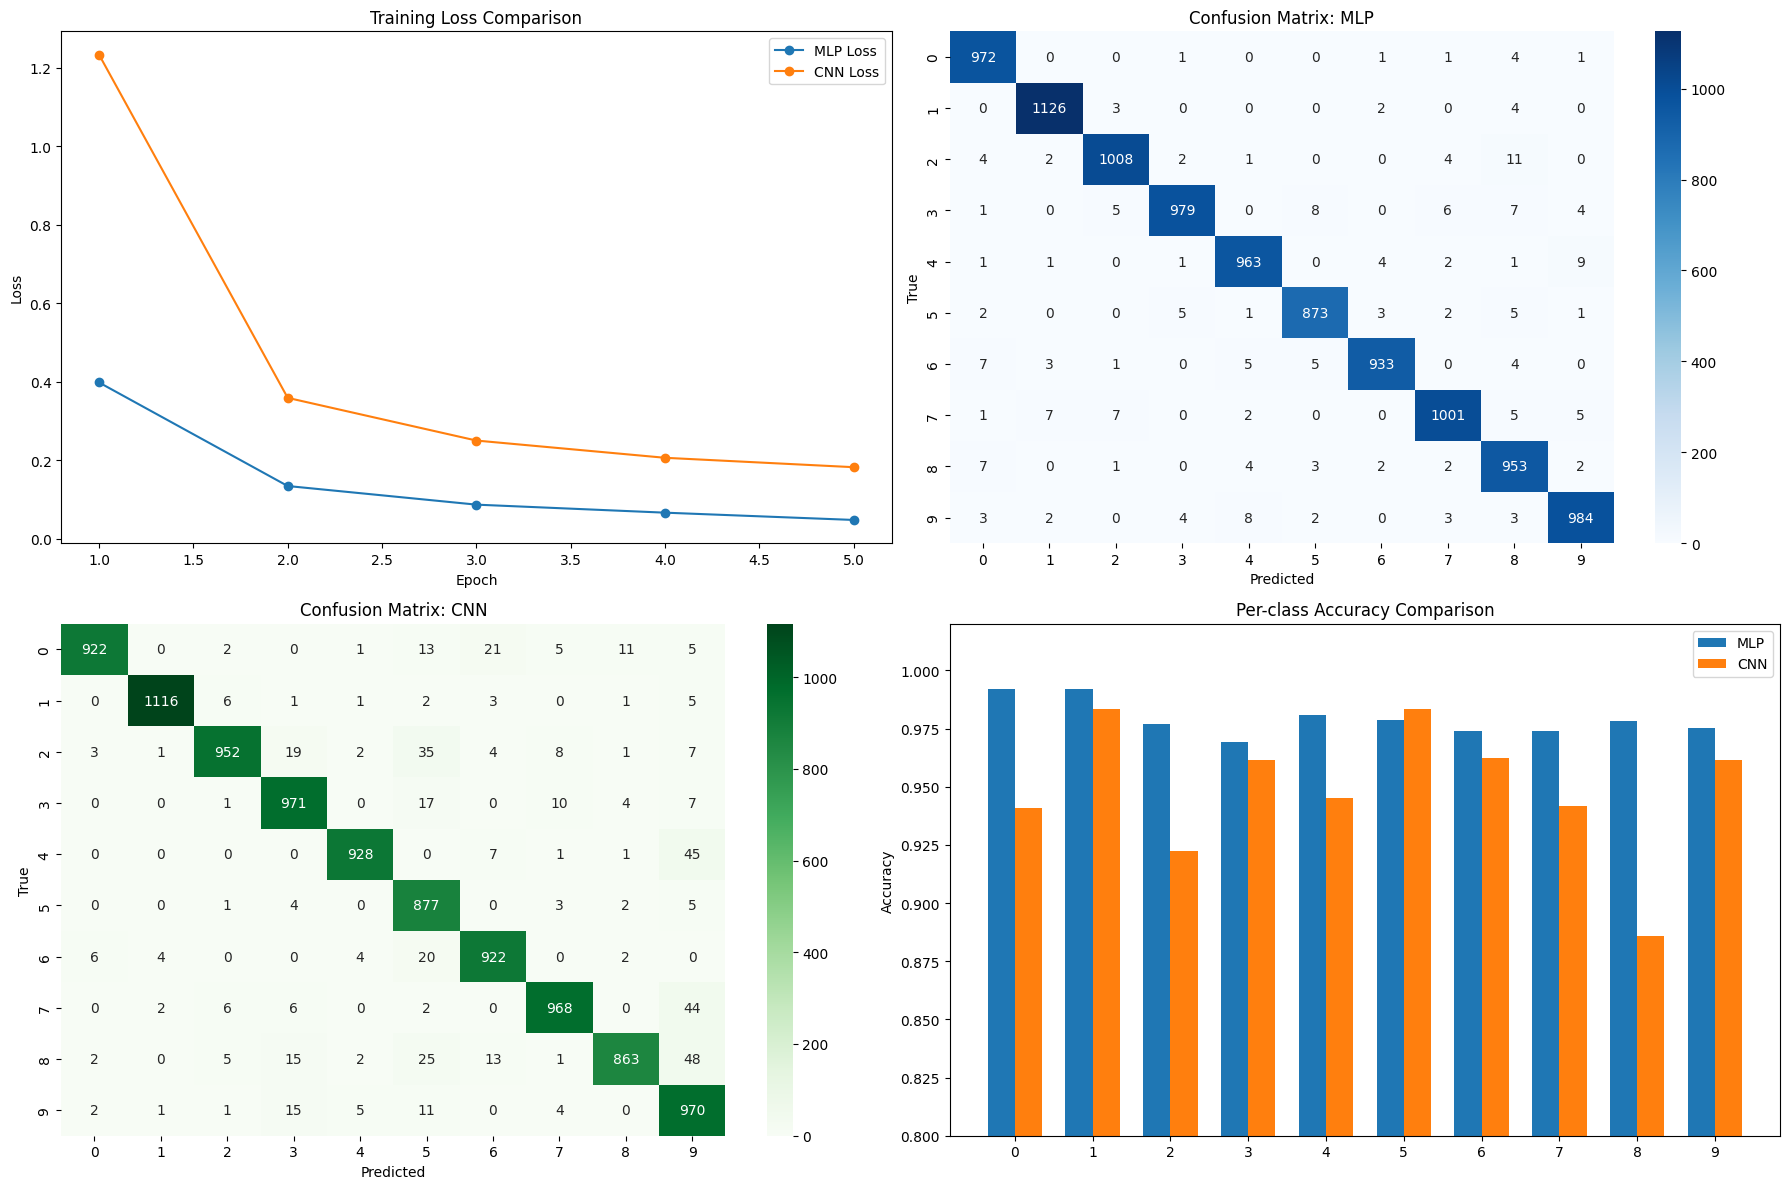

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. 모델 정의 (레이어 깊이를 비슷하게 설정)
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        # MLP: 3개의 Hidden Layer + 1개의 Output Layer
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*32, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.model(x)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # CNN: 3개의 Conv Layer + 1개의 FC Layer (깊이 유사)
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 10)
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# 2. 공통 학습 환경 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 5
lr = 0.001

def train_model(model, train_loader):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history.append(epoch_loss / len(train_loader))
    return history

# 3. 학습 및 결과 수집
mlp_model = MLP()
cnn_model = SimpleCNN()

print("Training MLP...")
mlp_history = train_model(mlp_model, train_loader)
print("Training CNN...")
cnn_history = train_model(cnn_model, train_loader)

# 4. 시각화 함수 (다양한 지표 추가)
def evaluate_and_plot(models, names, test_loader, histories):
    fig = plt.figure(figsize=(18, 12))

    # (1) Loss Graph
    plt.subplot(2, 2, 1)
    for hist, name in zip(histories, names):
        plt.plot(range(1, epochs+1), hist, marker='o', label=f'{name} Loss')
    plt.title('Training Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # 클래스별 정확도 계산을 위한 준비
    all_results = []

    for idx, (model, name) in enumerate(zip(models, names)):
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                out = model(data)
                preds.extend(out.argmax(1).cpu().numpy())
                targets.extend(target.cpu().numpy())

        cm = confusion_matrix(targets, preds)
        all_results.append((cm, targets, preds))

        # (2) Confusion Matrix
        plt.subplot(2, 2, idx + 2)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if idx==0 else 'Greens')
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted')
        plt.ylabel('True')

    # (3) Per-class Accuracy Comparison (추가 시각화)
    plt.subplot(2, 2, 4)
    x = np.arange(10)
    width = 0.35

    for i, (cm, _, _) in enumerate(all_results):
        class_acc = cm.diagonal() / cm.sum(axis=1)
        plt.bar(x + (i*width - width/2), class_acc, width, label=names[i])

    plt.title('Per-class Accuracy Comparison')
    plt.xticks(x, [str(i) for i in range(10)])
    plt.ylim(0.8, 1.02) # 차이를 보기 위해 y축 범위 조정
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

evaluate_and_plot([mlp_model, cnn_model], ['MLP', 'CNN'], test_loader, [mlp_history, cnn_history])

#### 성능 차이의 원인: 파라미터 수
CNN은 파라미터 공유(Weight Sharing) 덕분에 MLP보다 훨씬 적은 파라미터로도 높은 성능

만약 학습 데이터가 매우 적거나 모델이 너무 단순하면, CNN의 특징 추출 능력이 충분히 발휘되지 않을 수 있음


In [ ]:
import torch
import torch.nn as nn


mlp = MLP().to(device)
cnn = SimpleCNN().to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"MLP 파라미터 수: {count_parameters(mlp):,}")
print(f"CNN 파라미터 수: {count_parameters(cnn):,}")

MLP 파라미터 수: 690,314
CNN 파라미터 수: 93,962


#### CNN 성능 향상 방법
- 모델 파라미터 증강(Model Capacity Expansion): 합성곱 필터의 개수와 은닉층의 깊이를 늘려 복잡한 데이터 패턴을 학습할 수 있도록 모델의 비선형적 표현력을 향상시킴.
- 데이터 증강(Data Augmentation): 회전, 반전 등을 통해 데이터 다양성 확보
- 배치 정규화(Batch Normalization): 학습 속도 및 안정성 향상
- 드롭아웃(Dropout): 과적합 방지
- 깊은 아키텍처(ResNet 등): 잔차 연결을 통해 더 깊은 특징 추출

In [ ]:
class SimpleCNN(nn.Module): # 모델 구조를 변경하여 CNN 구성해보기
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # CNN: 3개의 Conv Layer + 1개의 FC Layer (깊이 유사)
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(64, 10)
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# 2. 공통 학습 환경 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 5
lr = 0.001

def train_model(model, train_loader):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history.append(epoch_loss / len(train_loader))
    return history

# 3. 학습 및 결과 수집
mlp_model = MLP()
cnn_model = SimpleCNN()

print("Training MLP...")
#mlp_history = train_model(mlp_model, train_loader)
print("Training CNN...")
cnn_history = train_model(cnn_model, train_loader)

# 4. 시각화 함수 (다양한 지표 추가)
def evaluate_and_plot(models, names, test_loader, histories):
    fig = plt.figure(figsize=(18, 12))

    # (1) Loss Graph
    plt.subplot(2, 2, 1)
    for hist, name in zip(histories, names):
        plt.plot(range(1, epochs+1), hist, marker='o', label=f'{name} Loss')
    plt.title('Training Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # 클래스별 정확도 계산을 위한 준비
    all_results = []

    for idx, (model, name) in enumerate(zip(models, names)):
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                out = model(data)
                preds.extend(out.argmax(1).cpu().numpy())
                targets.extend(target.cpu().numpy())

        cm = confusion_matrix(targets, preds)
        all_results.append((cm, targets, preds))

        # (2) Confusion Matrix
        plt.subplot(2, 2, idx + 2)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if idx==0 else 'Greens')
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted')
        plt.ylabel('True')

    # (3) Per-class Accuracy Comparison (추가 시각화)
    plt.subplot(2, 2, 4)
    x = np.arange(10)
    width = 0.35

    for i, (cm, _, _) in enumerate(all_results):
        class_acc = cm.diagonal() / cm.sum(axis=1)
        plt.bar(x + (i*width - width/2), class_acc, width, label=names[i])

    plt.title('Per-class Accuracy Comparison')
    plt.xticks(x, [str(i) for i in range(10)])
    plt.ylim(0.8, 1.02) # 차이를 보기 위해 y축 범위 조정
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

evaluate_and_plot([mlp_model, cnn_model], ['MLP', 'CNN'], test_loader, [mlp_history, cnn_history])

Training MLP...
Training CNN...


KeyboardInterrupt: 

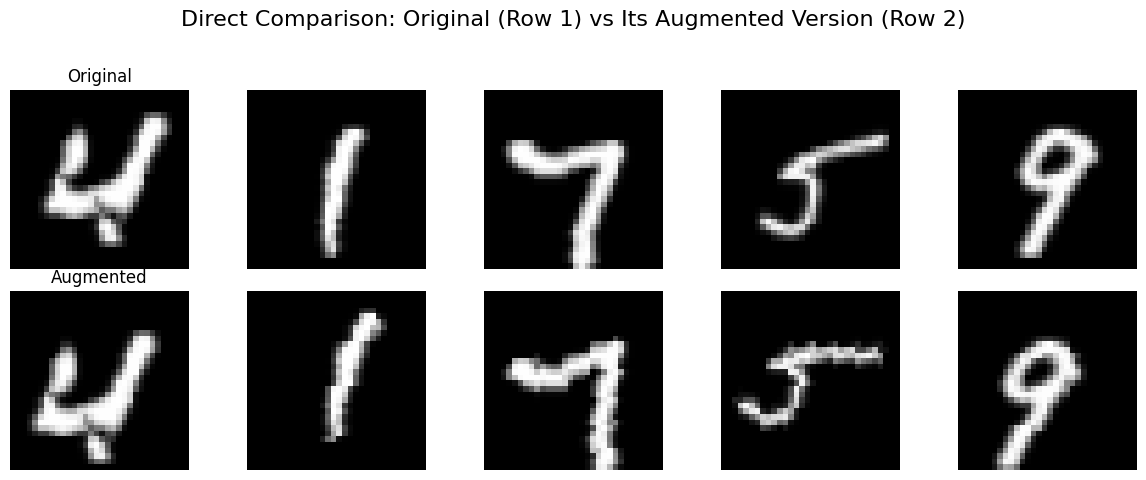

Training MLP with Augmentation...
Training CNN with Augmentation...


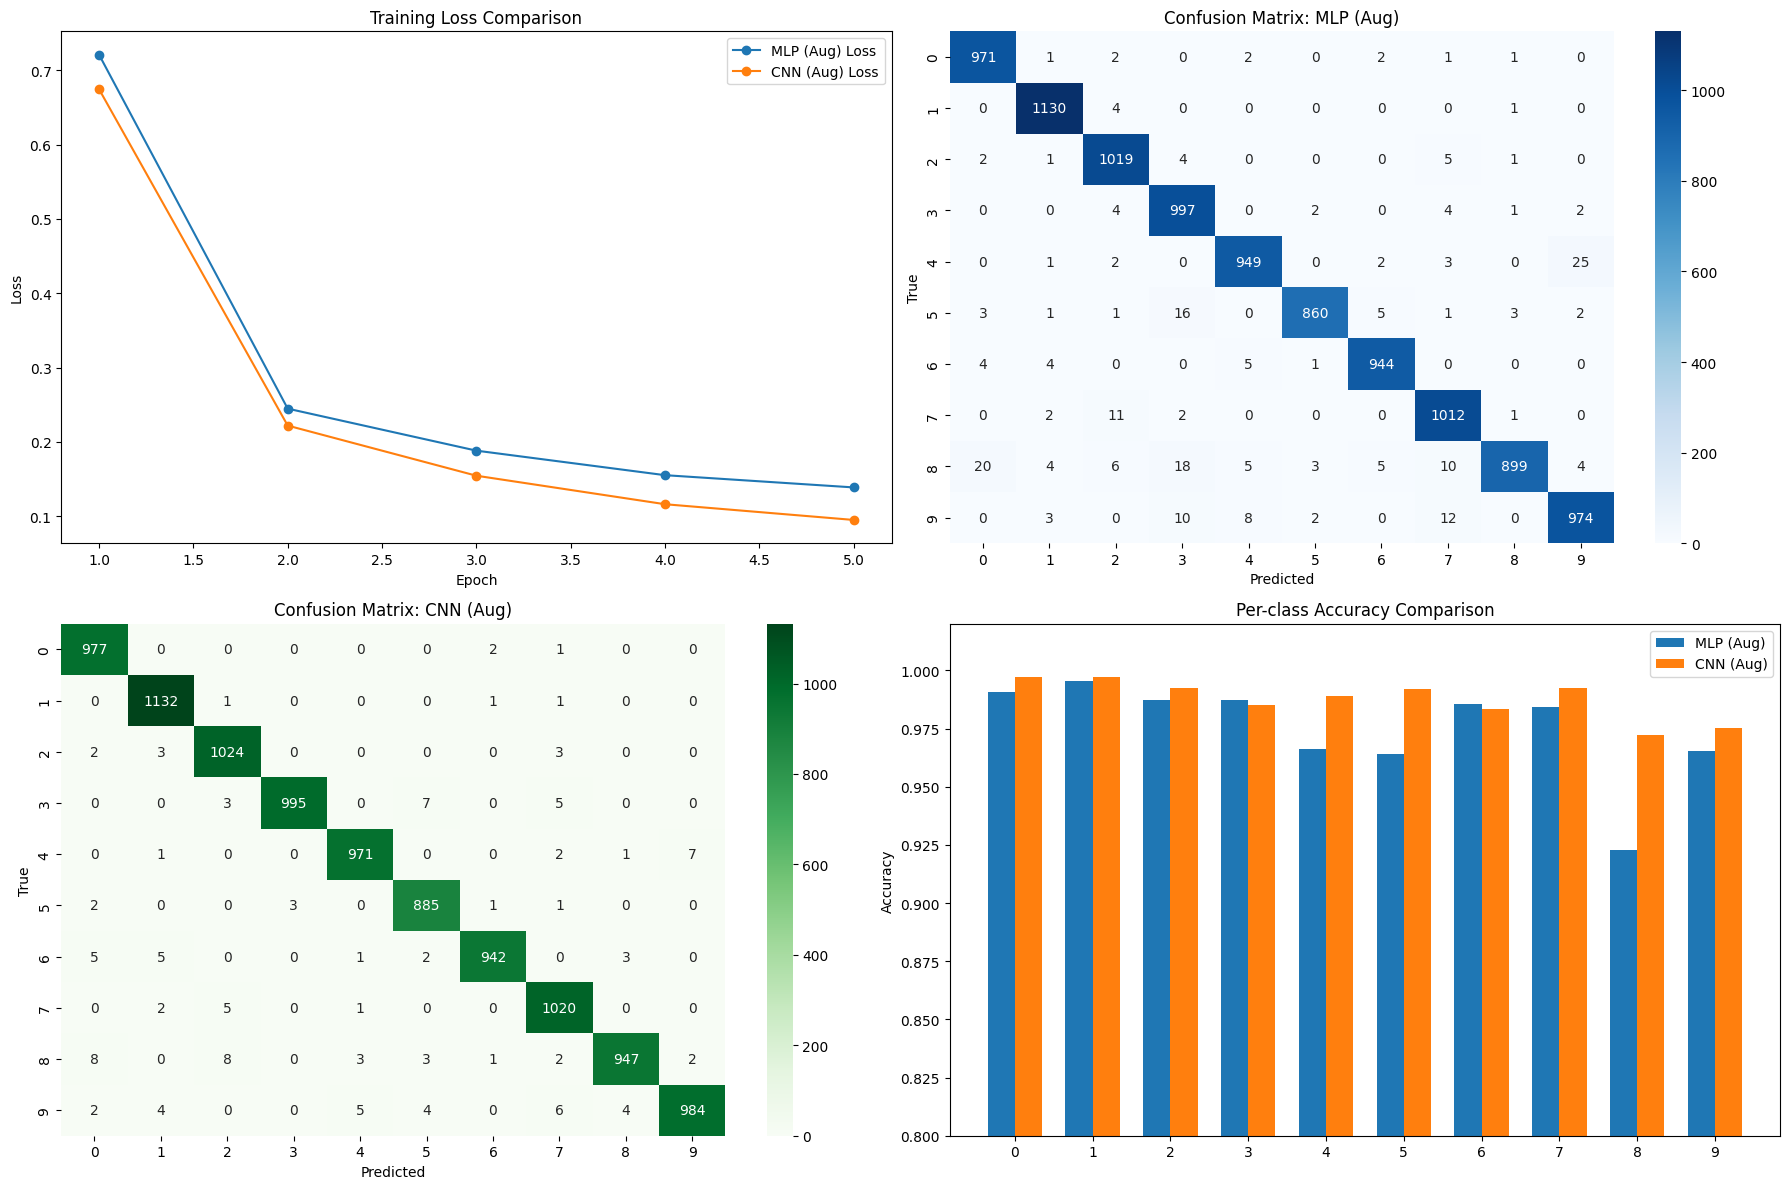

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. 데이터 증강(Data Augmentation) 정의
aug_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(15),      # 최대 15도 무작위 회전
    transforms.RandomAffine(0, translate=(0.1, 0.1)), # 무작위 평행 이동
    transforms.ToTensor()
])

# 증강된 학습 데이터 로더
aug_train_data = datasets.MNIST('./data', train=True, download=True, transform=aug_transform)
aug_train_loader = torch.utils.data.DataLoader(aug_train_data, batch_size=256, shuffle=True)

# 2. 동일한 이미지에 대한 원본 vs 증강 비교 시각화
def show_aug_comparison(loader, transform):
    # 데이터 로더에서 한 배치를 가져옵니다.
    # (주의: 로더의 transform이 ToTensor() 등을 포함하고 있을 수 있으므로 raw 데이터를 확인하기 위해 런타임에 적용)
    data, _ = next(iter(loader))

    plt.figure(figsize=(12, 5))
    plt.suptitle('Direct Comparison: Original (Row 1) vs Its Augmented Version (Row 2)', fontsize=16)

    for i in range(5):
        # 원본 이미지 (이미 Tensor 형태일 경우 squeeze만 수행)
        orig_img = data[i]

        # 동일한 원본 이미지에 transform을 적용하여 증강된 이미지 생성
        # transforms.ToPILImage()를 사용하여 텐서를 이미지로 바꾼 뒤 다시 적용하거나,
        # 이미 텐서인 경우 적용 가능한 transform인지 확인 필요.
        # 여기서는 ToPILImage를 거쳐 확실하게 시각적 증강을 수행합니다.
        pil_img = transforms.ToPILImage()(orig_img)
        aug_img_tensor = transform(pil_img)

        # 첫 번째 줄: 원본
        plt.subplot(2, 5, i + 1)
        plt.imshow(orig_img.squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0: plt.title("Original")

        # 두 번째 줄: 해당 원본이 변형된 결과
        plt.subplot(2, 5, i + 6)
        plt.imshow(aug_img_tensor.squeeze(), cmap='gray')
        plt.axis('off')
        if i == 0: plt.title("Augmented")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 시각화 실행 (원본 train_loader의 데이터를 기반으로 실시간 변형 수행)
show_aug_comparison(train_loader, aug_transform)

# 3. 모델 초기화 및 학습 (데이터 증강 적용 버전)
mlp_aug = MLP().to(device)
cnn_aug = SimpleCNN().to(device)

print("Training MLP with Augmentation...")
mlp_aug_history = train_model(mlp_aug, aug_train_loader)

print("Training CNN with Augmentation...")
cnn_aug_history = train_model(cnn_aug, aug_train_loader)

# 4. 결과 비교 시각화
evaluate_and_plot([mlp_aug, cnn_aug], ['MLP (Aug)', 'CNN (Aug)'], test_loader, [mlp_aug_history, cnn_aug_history])

# CNN 모델을 기반으로 X-ray dataset 분류하기

본 세션에서는 Kaggle의 실제 임상 데이터인 Chest X-Ray Images (Pneumonia) 데이터셋을 활용한다.

실제 엑스레이 이미지를 $128 \times 128$ 해상도의 단일 채널(Grayscale)로 전처리하여 사용하며, 정상(Normal) 흉부와 폐렴(Pneumonia) 병변이 존재하는 흉부를 분류하는 이진 분류(Binary Classification) 테스크를 수행한다.

이를 통해 픽셀의 절대적 위치에 의존하는 다층 퍼셉트론(MLP)의 메모리 비효율성(Parameter Explosion)을 정량적으로 입증하고, 합성곱 신경망(CNN)이 병변의 공간적 특징(Spatial Feature)을 어떻게 효율적으로 추출하는지 대조해본다.

## Kaggle 데이터셋 다운로드 및 환경 설정

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# 1. Kaggle API 설정 및 데이터셋 다운로드

if not os.path.exists('chest_xray'):
    !pip install -q kaggle
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
    !unzip -q chest-xray-pneumonia.zip -d ./
    print("Dataset Download and Unzip Completed.")
else:
    print("Dataset already exists.")

# 2. 하이퍼파라미터 및 경로 설정
IMAGE_SIZE = 128
BATCH_SIZE = 512
DATA_DIR = './chest_xray'

# 3. 데이터 전처리 파이프라인 (Transforms)
# MLP의 파라미터 폭발을 관찰하기 위해 128x128 크기로 조정 및 Grayscale 변환 적용
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ImageFolder를 통한 데이터 로드
train_dataset = torchvision.datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=transform)
test_dataset = torchvision.datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:42<00:00, 15.2MB/s]

Dataset Download and Unzip Completed.


## 실제 엑스레이 데이터 시각화

폐렴 환자의 엑스레이는 정상 데이터와 달리 폐 야(Lung field)에 비정상적인 음영(Opacity)이 공간적으로 불규칙하게 분포함. 모델은 단순한 픽셀 값의 합이 아닌, 이 음영의 형태론적 패턴을 학습해야 함.

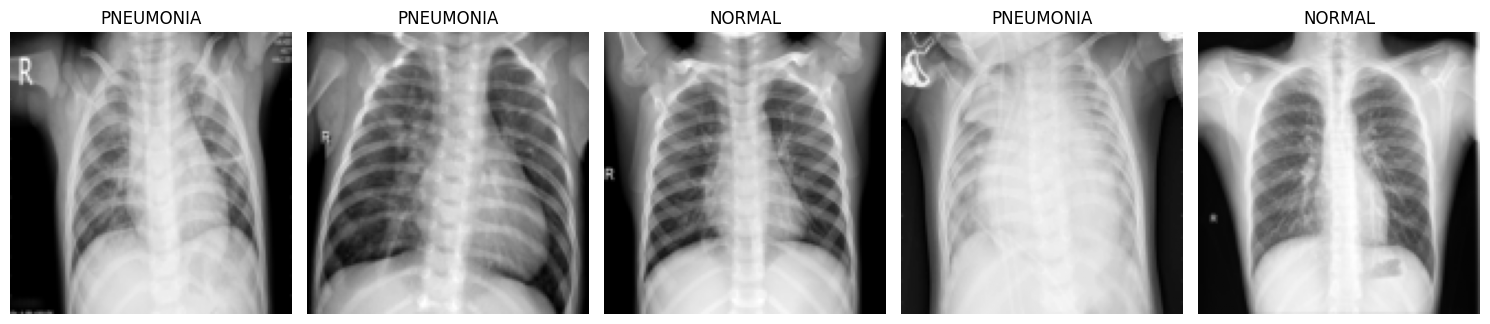

In [ ]:
# 4. 데이터셋 시각화 (Visualization)
def imshow(img):
    img = img * 0.5 + 0.5 # Unnormalize
    npimg = img.numpy()
    plt.imshow(npimg[0], cmap='gray')
    plt.axis('off')

# 무작위 샘플 추출
dataiter = iter(train_loader)
images, labels = next(dataiter)
classes = train_dataset.classes # ['NORMAL', 'PNEUMONIA']

plt.figure(figsize=(15, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    imshow(images[i])
    plt.title(classes[labels[i]])
plt.tight_layout()
plt.show()

## MLP와 CNN 아키텍처 정의

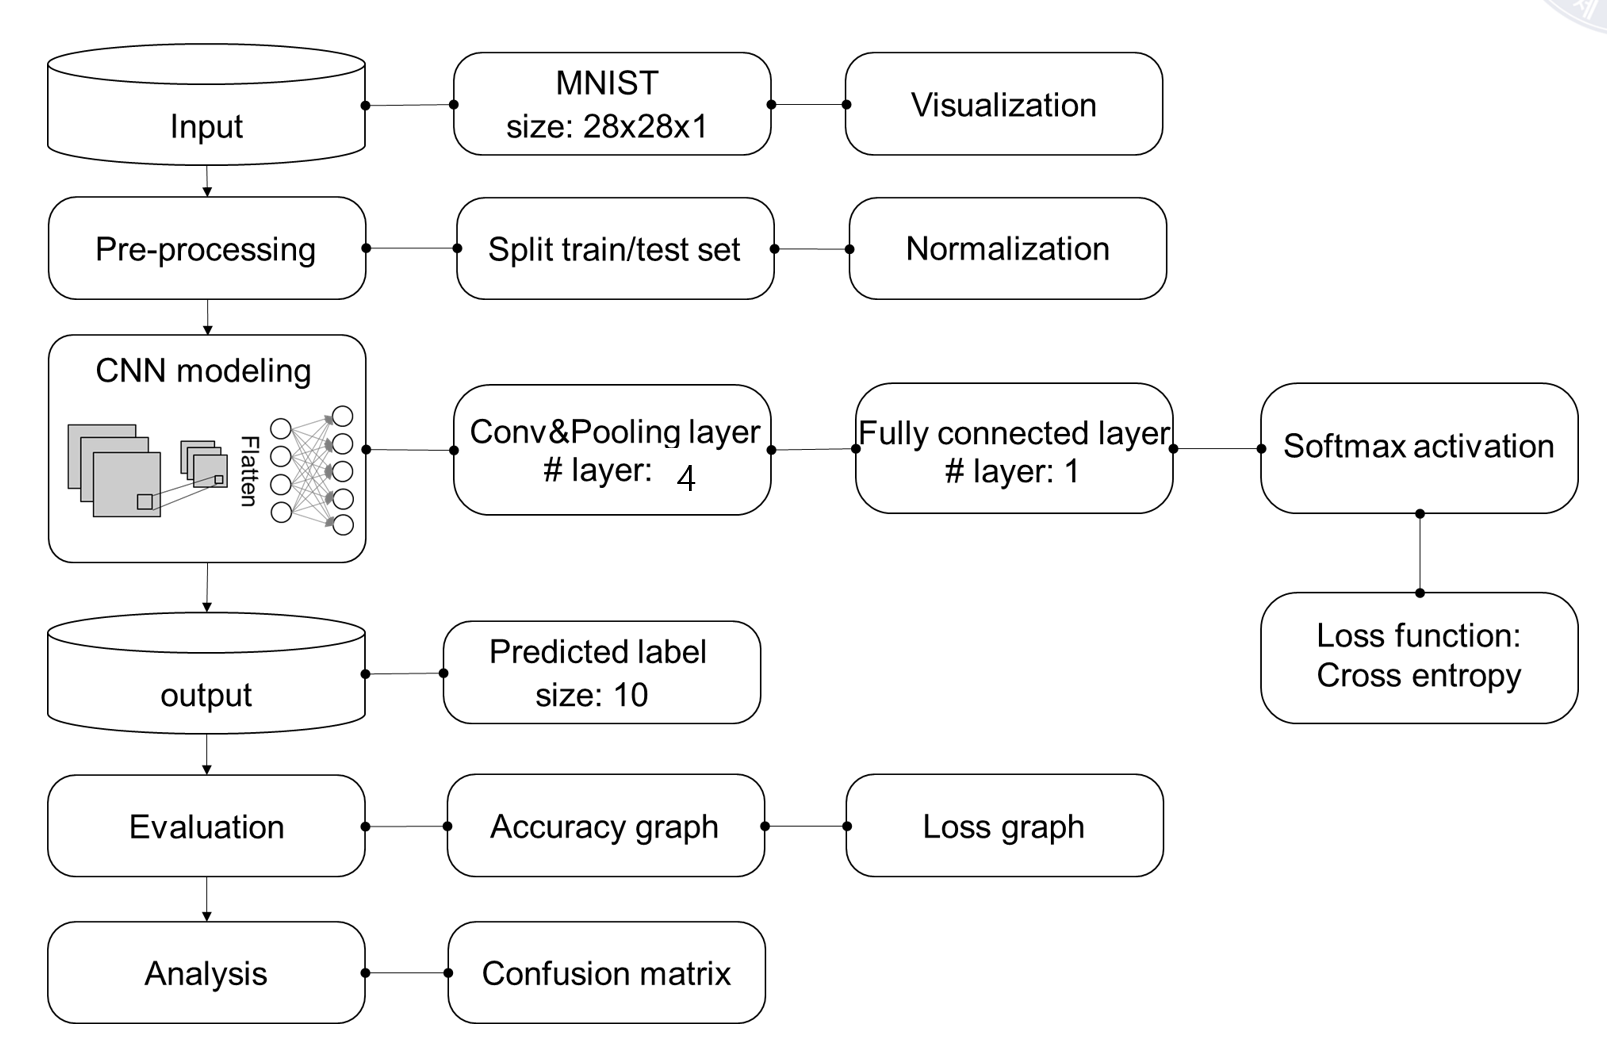

In [ ]:
# -----------------------------------------------------------
# 5. 모델 구조 정의 (Optimized)
# -----------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

class MedicalMLP(nn.Module):
    def __init__(self):
        super(MedicalMLP, self).__init__()
        self.flatten_dim = IMAGE_SIZE * IMAGE_SIZE # 16,384
        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.fc_out = nn.Linear(256, 2)

    def forward(self, x):
        x = x.view(-1, self.flatten_dim)
        x = F.relu(self.fc1(x))
        x = self.fc_out(x)
        return x

class OptimizedMedicalCNN(nn.Module):
    def __init__(self):
        super(OptimizedMedicalCNN, self).__init__()

        # Block 1: 1 -> 64
        self.conv1 = nn.Conv2d(1, 64, kernel_size=5, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)

        # Block 2: 64 -> 128
        self.conv2 = nn.Conv2d(64, 128, kernel_size=5, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Block 3: 128 -> 256 (표현력 확장)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)

        # Block 4: 256 -> 512 (Resolution: 16x16)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)

        # 정규화 및 풀링
        self.dropout = nn.Dropout2d(p=0.3)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_out = nn.Linear(512, 2)

    def forward(self, x):

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        # 마지막 Conv 계층에는 Pooling 생략 (CAM 해상도 보존 위함)
        x = F.relu(self.bn4(self.conv4(x)))
        self.feature_map = x # 역전파 및 CAM을 위해 특성 맵 보존 (Batch, 256, 16, 16)

        x = self.dropout(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc_out(x)
        return x

def print_params(model, name):
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{name}] Trainable Parameters: {params:,} 개")

mlp_model = MedicalMLP()
cnn_model = OptimizedMedicalCNN()

print("="*60)
print("[Architecture Parameter Comparison]")
print_params(mlp_model, "Medical MLP")
print_params(cnn_model, "Medical CNN")
print("="*60)

[Architecture Parameter Comparison]
[Medical MLP] Trainable Parameters: 4,195,074 개
[Medical CNN] Trainable Parameters: 1,684,866 개


## 실제 임상 데이터 기반 모델 병렬 학습 및 일반화 성능 평가

파라미터가 과도한 MLP는 엑스레이의 뼈나 장비 노이즈 같은 무의미한 픽셀 패턴을 암기하여 과적합(Overfitting)에 빠지게 됨. 반면 CNN은 합성곱 연산을 통해 폐렴의 특징적인 음영(불투명도)이라는 국소적 특질에 집중하므로 테스트 데이터에서도 강건한 성능을 발휘함.

In [ ]:
# -----------------------------------------------------------
# 6. 학습 (Training) 및 검증 로직 (Loss 기록 추가)
# -----------------------------------------------------------
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_model.to(device)
cnn_model.to(device)

def train_and_eval(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()
    test_acc_history = []
    train_loss_history = []
    test_loss_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        train_pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}] Train", leave=False)
        for batch_X, batch_y in train_pbar:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            train_pbar.set_postfix(loss=loss.item())

        avg_train_loss = running_loss / len(train_loader)
        train_loss_history.append(avg_train_loss)

        # 평가 (Test)
        model.eval()
        correct = 0
        total = 0
        running_test_loss = 0.0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                loss = criterion(outputs, y)
                running_test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_test_loss = running_test_loss / len(test_loader)
        test_loss_history.append(avg_test_loss)

        acc = correct / total
        test_acc_history.append(acc)
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_train_loss:.4f}, Test Acc: {acc*100:.2f}%")

    return train_loss_history, test_loss_history, test_acc_history

print(f"[{device}] 환경에서 학습을 시작합니다.")
print("\n--- Training Medical MLP ---")
mlp_results = train_and_eval(mlp_model, optim.Adam(mlp_model.parameters(), lr=0.001))

print("\n--- Training Medical CNN ---")
cnn_results = train_and_eval(cnn_model, optim.Adam(cnn_model.parameters(), lr=0.001))

[cuda] 환경에서 학습을 시작합니다.

--- Training Medical MLP ---


Epoch [1/10] Train:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch [1/10] Loss: 1.2217, Test Acc: 73.56%


Epoch [2/10] Train:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch [2/10] Loss: 0.2202, Test Acc: 79.65%


...

Epoch [8/10] Loss: 0.0972, Test Acc: 83.65%


Epoch [9/10] Train:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch [9/10] Loss: 0.0895, Test Acc: 71.63%


Epoch [10/10] Train:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch [10/10] Loss: 0.0874, Test Acc: 85.74%


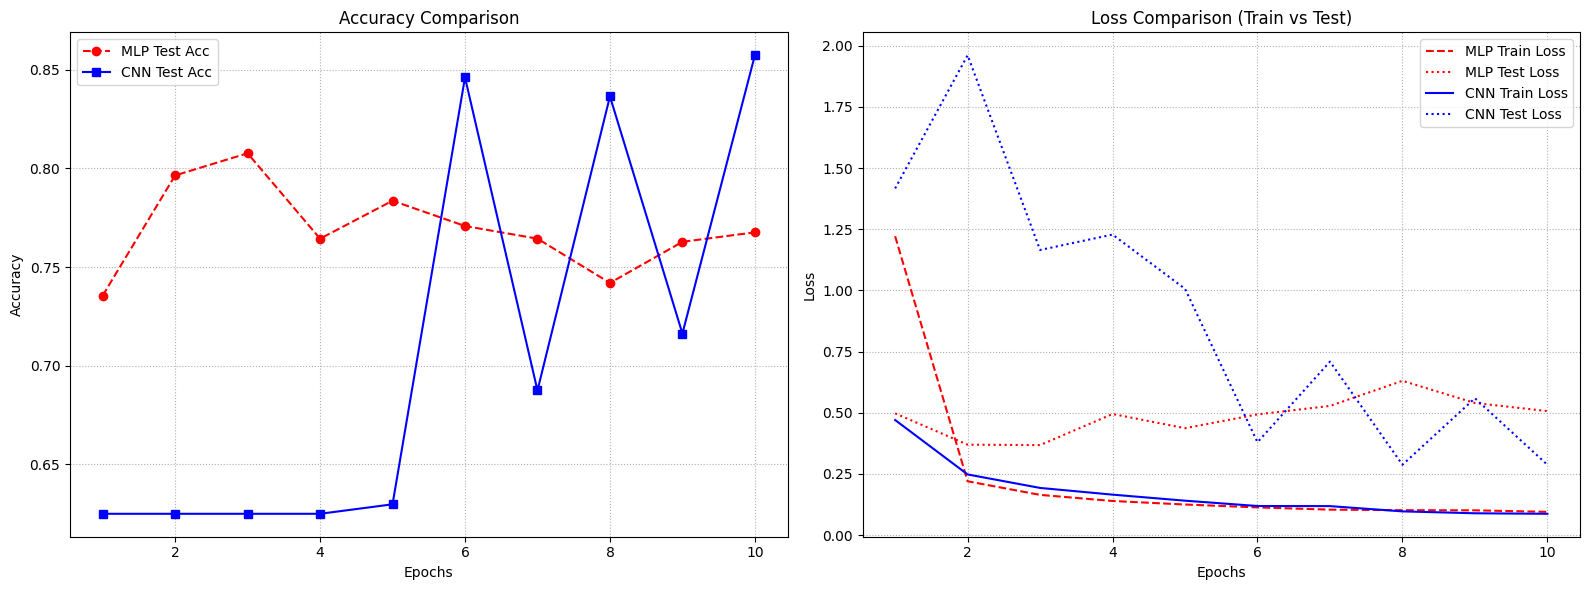

In [ ]:
# -----------------------------------------------------------
# 7. 성능 및 손실(Loss) 시각화
# -----------------------------------------------------------
mlp_train_loss, mlp_test_loss, mlp_acc = mlp_results
cnn_train_loss, cnn_test_loss, cnn_acc = cnn_results

plt.figure(figsize=(16, 6))
epochs_range = range(1, 11)

# (1) Accuracy 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs_range, mlp_acc, 'r--', marker='o', label='MLP Test Acc')
plt.plot(epochs_range, cnn_acc, 'b-', marker='s', label='CNN Test Acc')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle=':')

# (2) Loss 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, mlp_train_loss, 'r--', label='MLP Train Loss')
plt.plot(epochs_range, mlp_test_loss, 'r:', label='MLP Test Loss')
plt.plot(epochs_range, cnn_train_loss, 'b-', label='CNN Train Loss')
plt.plot(epochs_range, cnn_test_loss, 'b:', label='CNN Test Loss')
plt.title('Loss Comparison (Train vs Test)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

## CNN 해석 가능성(Explainability) 분석: Class Activation Map (CAM) 시각화

의료 도메인에서 딥러닝 모델의 신뢰성을 확보하기 위해서는 판단 근거의 시각화가 필수적임. 제안하는 CNN 모델의 Global Average Pooling(GAP) 구조를 활용하면, 병변(Pneumonia)을 판별할 때 엑스레이의 어느 부위에 가중치를 집중했는지 히트맵(Heatmap) 형태로 도출할 수 있음. 이는 위치 불변성을 지니는 CNN에서만 수학적으로 유도 가능한 성질임.

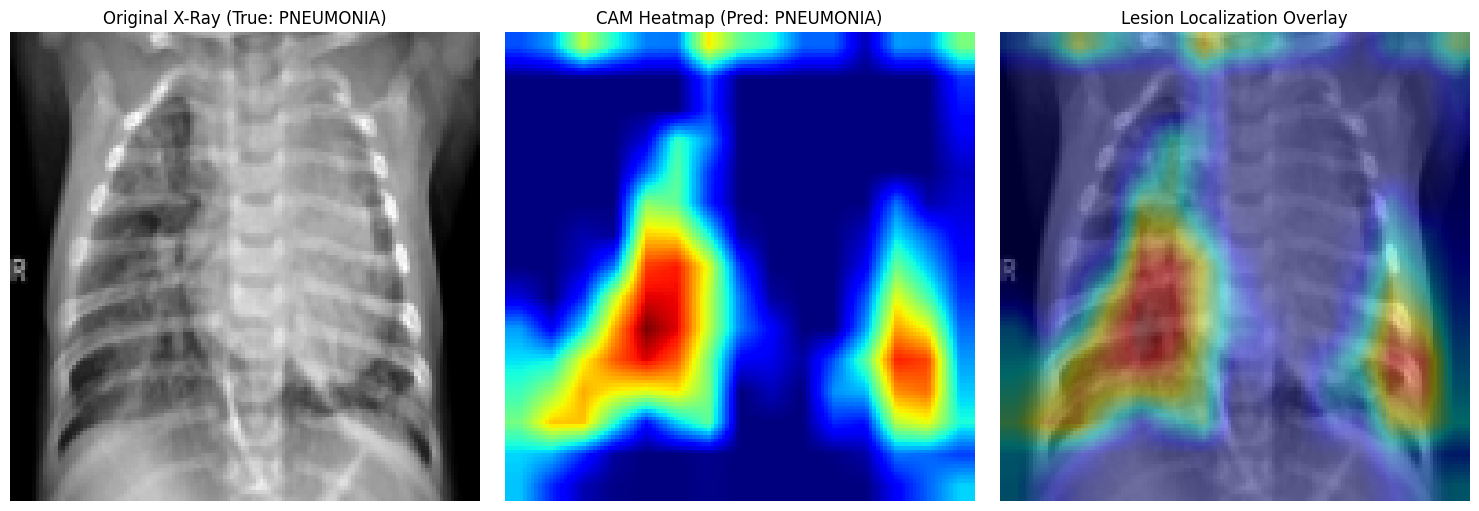

해석: 붉은색 활성화 영역(High Activation)은 네트워크가 폐렴 징후(Opacity)로 인식한 위치론적 근거를 나타냄.


In [ ]:
# -----------------------------------------------------------
# 8. CNN 판단 근거 시각화 (Class Activation Map)
# -----------------------------------------------------------
import cv2

cnn_model.eval()
cnn_model.to('cpu')

# 테스트셋에서 폐렴(PNEUMONIA) 샘플 추출
pneumonia_idx = classes.index('PNEUMONIA')
sample_img, sample_label = None, None

for img, label in test_dataset:
    if label == pneumonia_idx:
        sample_img, sample_label = img, label
        break

sample_tensor = sample_img.unsqueeze(0)

with torch.no_grad():
    output = cnn_model(sample_tensor)
    pred_class = output.argmax(1).item()

    # 합성곱 계층의 마지막 특징 맵 (Shape: [64, 16, 16])
    feature_map = cnn_model.feature_map.squeeze(0)

    # 최종 출력층(FC)의 가중치 추출
    fc_weights = cnn_model.fc_out.weight.data

    # 예측 클래스 가중치와 특징 맵의 선형 결합
    target_weight = fc_weights[pred_class]
    cam = torch.zeros(feature_map.shape[1:], dtype=torch.float32)
    for i, w in enumerate(target_weight):
        cam += w * feature_map[i]

    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam_np = cam.numpy()

# 128x128 원본 해상도로 보간
cam_resized = cv2.resize(cam_np, (IMAGE_SIZE, IMAGE_SIZE))

# 정규화 해제
img_np = sample_img.numpy()[0] * 0.5 + 0.5
img_np = np.clip(img_np, 0, 1)

# Heatmap 오버레이
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
# 흑백 이미지에 색상 입히기 위해 3채널 복사
img_color = np.stack((img_np,)*3, axis=-1)
overlay = heatmap * 0.4 + img_color * 0.6
overlay = np.clip(overlay, 0, 1)

# 시각화 플롯
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np, cmap='gray')
axes[0].set_title(f'Original X-Ray (True: {classes[sample_label]})')
axes[0].axis('off')

axes[1].imshow(cam_resized, cmap='jet')
axes[1].set_title(f'CAM Heatmap (Pred: {classes[pred_class]})')
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title('Lesion Localization Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()